# EDA with Kaggle dataset

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb


print("All imports successful!")

All imports successful!


In [88]:
#Loading and exploring dataset

df = pd.read_csv('/Users/mgmanjusha/Documents/NEU/Spring_26/FAI/Final Project/Machine-Learning-Based-Price-Fairness-Analysis-for-Laptop-E-Commerce/data/raw/laptop_cleaned2.csv')
df.head()

,Unnamed: 0,Name,Brand,Price,Rating,Processor_brand,Processor_name,Processor_variant,Processor_gen,Core_per_processor,...,Graphics_name,Graphics_brand,Graphics_GB,Graphics_integreted,Display_size_inches,Horizontal_pixel,Vertical_pixel,ppi,Touch_screen,Operating_system
0,0,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,HP,50399,4.30,AMD,AMD Ryzen 5,5600H,5.0,6.0,...,AMD Radeon RX 6500M,AMD,4.0,False,15.6,1920,1080,141.21,True,Windows 11 OS
1,1,Lenovo V15 G4 ‎82YU00W7IN Laptop (AMD Ryzen 3 ...,Lenovo,26690,4.45,AMD,AMD Ryzen 3,7320U,7.0,4.0,...,AMD Radeon Graphics,AMD,NaN,False,15.6,1920,1080,141.21,False,Windows 11 OS
2,2,HP 15s-fq5007TU Laptop (12th Gen Core i3/ 8GB/...,HP,37012,4.65,Intel,Intel Core i3,1215U,12.0,6.0,...,Intel UHD Graphics,Intel,NaN,False,15.6,1920,1080,141.21,False,Windows 11 OS
3,3,Samsung Galaxy Book2 Pro 13 Laptop (12th Gen C...,Samsung,69990,4.75,Intel,Intel Core i5,1240P,12.0,12.0,...,Intel Iris Xe Graphics,Intel,NaN,False,13.3,1080,1920,165.63,False,Windows 11 OS
4,4,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,Tecno,23990,4.25,Intel,Intel Core i3,1115G4,11.0,2.0,...,Intel UHD Graphics,Intel,NaN,False,15.6,1920,1080,141.21,False,Windows 11 OS


In [89]:
print("Shape: ",df.shape)

Shape:  (1020, 29)


In [90]:
print("Info: \n",df.info)

Info: 
 <bound method DataFrame.info of       Unnamed: 0                                               Name    Brand  \
0              0  HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...       HP   
1              1  Lenovo V15 G4 ‎82YU00W7IN Laptop (AMD Ryzen 3 ...   Lenovo   
2              2  HP 15s-fq5007TU Laptop (12th Gen Core i3/ 8GB/...       HP   
3              3  Samsung Galaxy Book2 Pro 13 Laptop (12th Gen C...  Samsung   
4              4  Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...    Tecno   
...          ...                                                ...      ...   
1015        1015              MSI Creator Z17 HX Studio A13V Laptop      MSI   
1016        1016  MSI Stealth 16 Mercedes AMG Motorsport A13V Ga...      MSI   
1017        1017  HP Victus 15-fb0131AX Gaming Laptop (AMD Ryzen...       HP   
1018        1018  Asus Vivobook 16 2023 M1605YA-MB521WS Laptop (...     Asus   
1019        1019  Dell Inspiron 7630 IC7630GHHRH001ORS1 2 in 1 L...     Dell   


                     count    percent
Graphics_GB            652  63.921569
Total_processor        447  43.823529
Execution_units        447  43.823529
Processor_gen          129  12.647059
Threads                 48   4.705882
Processor_variant       24   2.352941
RAM_type                22   2.156863
Core_per_processor      12   1.176471
Graphics_integreted      2   0.196078
Graphics_brand           2   0.196078
Graphics_name            2   0.196078


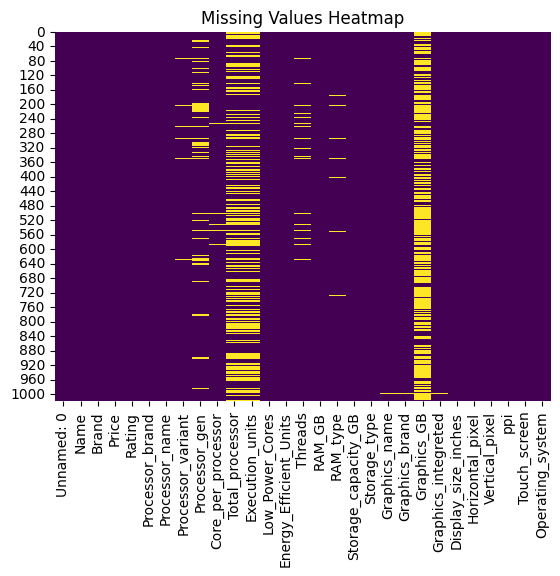

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count and percentage
missing = pd.DataFrame({
    'count': df.isnull().sum(),
    'percent': (df.isnull().sum() / len(df) * 100)
}).sort_values('percent', ascending=False)

print(missing[missing['count'] > 0])

# Visual
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [92]:
# Step 1: Drop high-missing columns
df.drop(columns=['Graphics_GB', 'Total_processor', 'Execution_units'], inplace=True)

# Verify
print("Shape after drop:", df.shape)
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape after drop: (1020, 26)
Processor_variant       24
Processor_gen          129
Core_per_processor      12
Threads                 48
RAM_type                22
Graphics_name            2
Graphics_brand           2
Graphics_integreted      2
dtype: int64


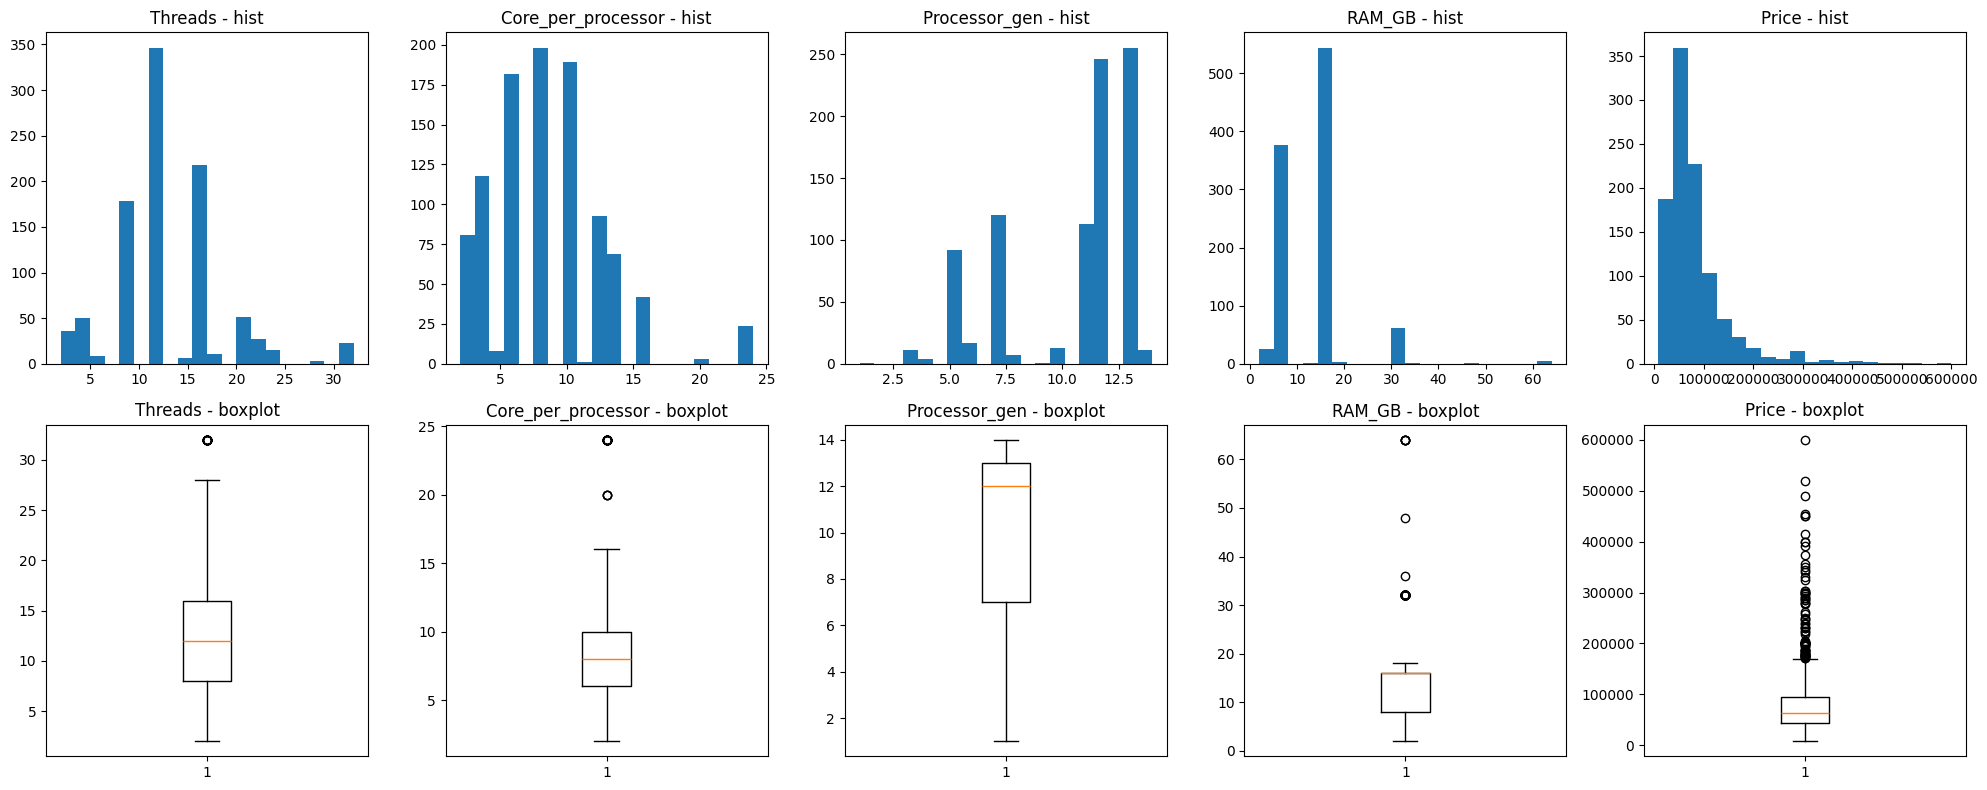

Skewness:
Threads               0.786769
Core_per_processor    1.038242
Processor_gen        -0.959187
RAM_GB                2.471612
Price                 3.023740
dtype: float64


In [93]:
#Before we impute other columns, choosing imputation technique is needed
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Threads', 'Core_per_processor', 'Processor_gen', 'RAM_GB', 'Price']

fig, axes = plt.subplots(2, len(num_cols), figsize=(20, 8))

for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df[col].dropna(), bins=20)
    axes[0, i].set_title(f'{col} - hist')
    
    # Boxplot
    axes[1, i].boxplot(df[col].dropna())
    axes[1, i].set_title(f'{col} - boxplot')

plt.tight_layout()
plt.show()

# Skewness values
print("Skewness:")
print(df[num_cols].skew())

In [94]:
# Step 2: Correct syntax
for col in ['Threads', 'Core_per_processor', 'Processor_gen']:
    df[col] = df[col].fillna(df[col].median())

# Verify
print(df[['Threads', 'Core_per_processor', 'Processor_gen']].isnull().sum())

Threads               0
Core_per_processor    0
Processor_gen         0
dtype: int64


In [95]:
# Check distribution of categorical columns with missing values
cat_cols = ['Processor_variant', 'RAM_type', 'Graphics_name', 'Graphics_brand', 'Graphics_integreted']

for col in cat_cols:
    print(f"\n{col} — {df[col].nunique()} unique values")
    print(df[col].value_counts())


Processor_variant — 125 unique values
Processor_variant
1235U        60
1215U        50
12450H       49
1335U        38
1115G4       32
             ..
processor     1
1195G7        1
10510U        1
SQ1           1
5500u         1
Name: count, Length: 125, dtype: int64

RAM_type — 12 unique values
RAM_type
DDR4       522
DDR5       188
LPDDR5     173
LPDDR4X     53
LPDDR5X     38
LPDDR4      16
DDR3         2
LPDDRX4      2
Unified      1
DDR6         1
LPDDR3       1
PDDR5X       1
Name: count, dtype: int64

Graphics_name — 136 unique values
Graphics_name
Intel Iris Xe Graphics           100
Intel UHD Graphics                84
NVIDIA GeForce RTX 3050           75
Intel Integrated Iris Xe          67
Intel Integrated UHD              62
                                ... 
Arm Mali-G72 MP3 Graphics          1
Intel Integrated ARC A530M         1
Intel Integrated ARC Graphics      1
Intel HD                           1
NVIDIA GEFORCE RTX 4050            1
Name: count, Length: 136, dt

In [96]:
# Fill with 'Unknown' where too diverse
for col in ['Processor_variant', 'Graphics_name']:
    df[col] = df[col].fillna('Unknown')

# Fill with mode where dominant value is clear
for col in ['RAM_type', 'Graphics_brand', 'Graphics_integreted']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify
print(df[['Processor_variant', 'RAM_type', 'Graphics_name', 'Graphics_brand', 'Graphics_integreted']].isnull().sum())

Processor_variant      0
RAM_type               0
Graphics_name          0
Graphics_brand         0
Graphics_integreted    0
dtype: int64


/var/folders/8j/w4cf450n1sscq6nksr6976b40000gn/T/ipykernel_12348/536994709.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [97]:
# Check no missing values remain
print("Remaining missing values:")
print(df.isnull().sum())

# Check shape
print(f"\nFinal shape: {df.shape}")

Remaining missing values:
Unnamed: 0                0
Name                      0
Brand                     0
Price                     0
Rating                    0
Processor_brand           0
Processor_name            0
Processor_variant         0
Processor_gen             0
Core_per_processor        0
Low_Power_Cores           0
Energy_Efficient_Units    0
Threads                   0
RAM_GB                    0
RAM_type                  0
Storage_capacity_GB       0
Storage_type              0
Graphics_name             0
Graphics_brand            0
Graphics_integreted       0
Display_size_inches       0
Horizontal_pixel          0
Vertical_pixel            0
ppi                       0
Touch_screen              0
Operating_system          0
dtype: int64

Final shape: (1020, 26)


In [98]:
#Checking for duplicates
print(f"Total duplicates: {df.duplicated().sum()}")

# Preview duplicate rows if any
print(df[df.duplicated(keep=False)].sort_values('Name').head(10))

Total duplicates: 0
Empty DataFrame
Columns: [Unnamed: 0, Name, Brand, Price, Rating, Processor_brand, Processor_name, Processor_variant, Processor_gen, Core_per_processor, Low_Power_Cores, Energy_Efficient_Units, Threads, RAM_GB, RAM_type, Storage_capacity_GB, Storage_type, Graphics_name, Graphics_brand, Graphics_integreted, Display_size_inches, Horizontal_pixel, Vertical_pixel, ppi, Touch_screen, Operating_system]
Index: []

[0 rows x 26 columns]


In [99]:
#Understanding the Price column
#Price is in Rupees
# Basic info about price
print("Count:", df['Price'].count())
print("Missing values:", df['Price'].isnull().sum())
print("Min price:", df['Price'].min())
print("Max price:", df['Price'].max())
print("Mean price:", df['Price'].mean())
print("Median price:", df['Price'].median())
print("Standard deviation:", df['Price'].std())

Count: 1020
Missing values: 0
Min price: 8000
Max price: 599990
Mean price: 82063.47450980393
Median price: 63689.5
Standard deviation: 66502.15060661973


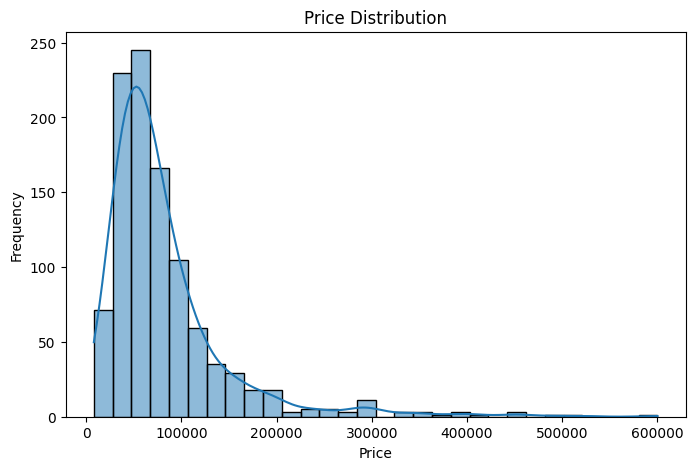

In [100]:
#Looking at the mean and median the data seemed slightly skewed
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [101]:
print("Skewness:", df['Price'].skew())

Skewness: 3.0237401709011986


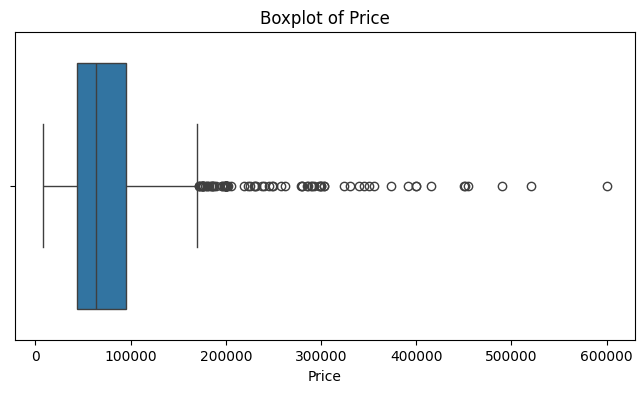

In [102]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of Price")
plt.show()

In [103]:
#Transforming the target variable
import numpy as np

df['Log_Price'] = np.log(df['Price'])

print("Skewness (Original):", df['Price'].skew())
print("Skewness (Log):", df['Log_Price'].skew())

Skewness (Original): 3.0237401709011986
Skewness (Log): 0.3468306356242124


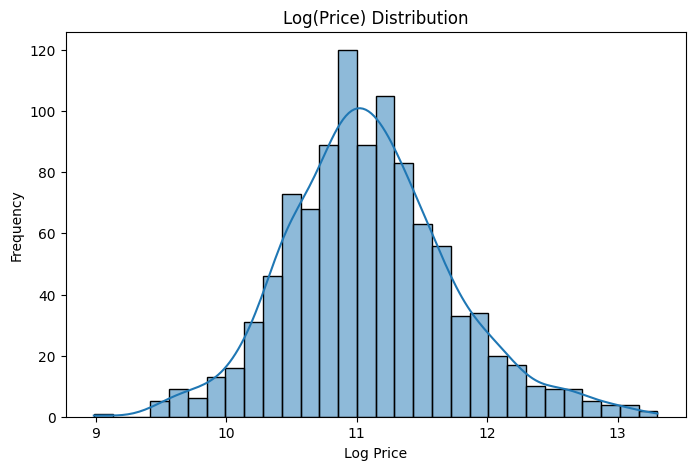

In [104]:
plt.figure(figsize=(8,5))
sns.histplot(df['Log_Price'], bins=30, kde=True)
plt.title("Log(Price) Distribution")
plt.xlabel("Log Price")
plt.ylabel("Frequency")
plt.show()

### confirmed that the price is now normally distributed

In [105]:
# checking numerical cols
df.select_dtypes(include=['int64', 'float64']).columns

Index(['Unnamed: 0', 'Price', 'Rating', 'Processor_gen', 'Core_per_processor',
       'Low_Power_Cores', 'Energy_Efficient_Units', 'Threads', 'RAM_GB',
       'Storage_capacity_GB', 'Display_size_inches', 'Horizontal_pixel',
       'Vertical_pixel', 'ppi', 'Log_Price'],
      dtype='object')

In [106]:
# Get all numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target and unwanted columns
remove_cols = ['Price', 'Log_Price', 'Unnamed: 0']

num_cols = [col for col in num_cols if col not in remove_cols]

num_cols

['Rating',
 'Processor_gen',
 'Core_per_processor',
 'Low_Power_Cores',
 'Energy_Efficient_Units',
 'Threads',
 'RAM_GB',
 'Storage_capacity_GB',
 'Display_size_inches',
 'Horizontal_pixel',
 'Vertical_pixel',
 'ppi']

In [107]:
df[num_cols].describe()

,Rating,Processor_gen,Core_per_processor,Low_Power_Cores,Energy_Efficient_Units,Threads,RAM_GB,Storage_capacity_GB,Display_size_inches,Horizontal_pixel,Vertical_pixel,ppi
count,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000
mean,4.373676,10.646078,8.565686,0.086275,0.043137,12.779412,13.992157,627.733333,15.163775,2035.512745,1214.019608,157.178265
std,0.233295,2.819955,4.349613,0.406531,0.203266,5.544836,7.189564,316.911679,1.001537,409.209289,306.863086,33.585713
min,3.950000,1.000000,2.000000,0.000000,0.000000,2.000000,2.000000,32.000000,11.600000,1080.000000,768.000000,100.450000
25%,4.200000,10.000000,6.000000,0.000000,0.000000,8.000000,8.000000,512.000000,14.000000,1920.000000,1080.000000,141.210000
50%,4.350000,12.000000,8.000000,0.000000,0.000000,12.000000,16.000000,512.000000,15.600000,1920.000000,1080.000000,141.210000
75%,4.550000,13.000000,10.000000,0.000000,0.000000,16.000000,16.000000,512.000000,15.600000,1920.000000,1200.000000,161.730000
max,4.750000,14.000000,24.000000,2.000000,1.000000,32.000000,64.000000,4000.000000,18.000000,3840.000000,2560.000000,337.930000


# Starting feature analysis on numeric cols

## RAM GB

In [108]:
# 1. Distribution
print("Value Counts:")
print(df['RAM_GB'].value_counts().sort_index())

print(f"\nSkewness: {df['RAM_GB'].skew():.2f}")
print(df['RAM_GB'].describe())

Value Counts:
RAM_GB
2       1
4      25
8     377
12      2
16    543
18      3
32     62
36      1
48      1
64      5
Name: count, dtype: int64

Skewness: 2.47
count    1020.000000
mean       13.992157
std         7.189564
min         2.000000
25%         8.000000
50%        16.000000
75%        16.000000
max        64.000000
Name: RAM_GB, dtype: float64


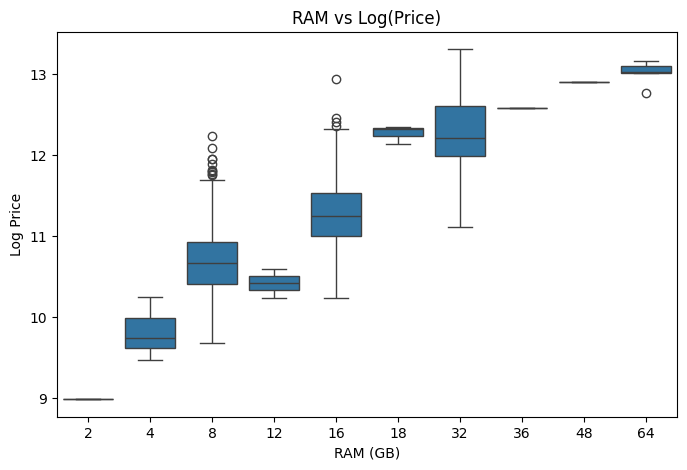

In [109]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['RAM_GB'], y=df['Log_Price'])
plt.title("RAM vs Log(Price)")
plt.xlabel("RAM (GB)")
plt.ylabel("Log Price")
plt.show()

## Observation

- Strong positive correlation between Log price and RAM GB i.e RAM GB increases with the price

Anomolies observed:

- 12GB < 8GB price, might be because omly 2 samples exist for 12 GB: not statistucally meaningful
- Some 32GB < 18GB only has 3 samples — too few to be reliable

Note for feature engineering: Binning RAM into tiers for modeling later will help. 

## Storage 

In [110]:
# 1. Distribution
print("Value Counts:")
print(df['Storage_capacity_GB'].value_counts().sort_index())

print(f"\nSkewness: {df['Storage_capacity_GB'].skew():.2f}")
print(df['Storage_capacity_GB'].describe())

Value Counts:
Storage_capacity_GB
32        1
64        9
128      19
256      46
512     702
1000    218
1256      4
1512      2
2000     18
4000      1
Name: count, dtype: int64

Skewness: 2.81
count    1020.000000
mean      627.733333
std       316.911679
min        32.000000
25%       512.000000
50%       512.000000
75%       512.000000
max      4000.000000
Name: Storage_capacity_GB, dtype: float64


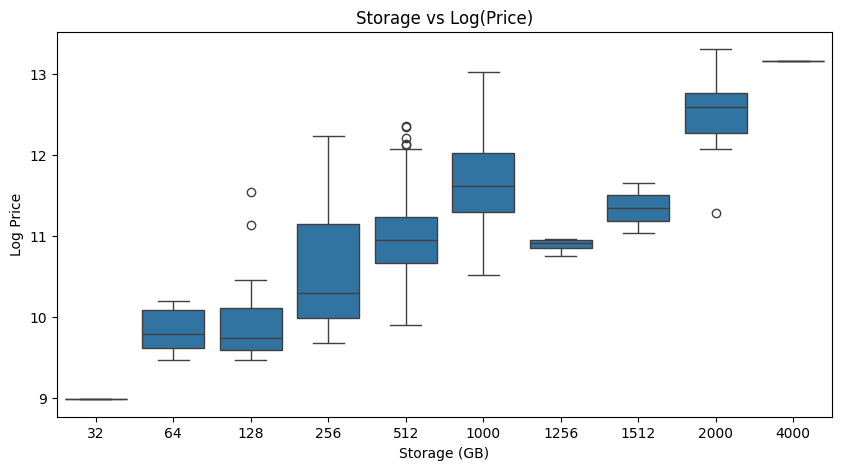

In [111]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Storage_capacity_GB'], y=df['Log_Price'])
plt.title("Storage vs Log(Price)")
plt.xlabel("Storage (GB)")
plt.ylabel("Log Price")
plt.show()

## Observation:
- Storage_capacity_GB shows a strong positive correlation with price. 

Anomolie observed:
- 1256GB and 1512GB drop below expected price trend

In [112]:
print(df[df['Storage_capacity_GB'].isin([1256, 1512])][['Name', 'Storage_capacity_GB', 'Price', 'Storage_type']])

                                                  Name  Storage_capacity_GB  \
66   MSI Thin GF63 11UC-1490IN Gaming Laptop (11th ...                 1256   
267  MSI GF63 Thin 11SC-1298IN Gaming Laptop (11th ...                 1256   
290  HP 15s-du3614TU Laptop (11th Gen Core i3/ 8GB/...                 1256   
817  MSI Thin GF63 11UCX-1492IN Gaming Laptop (11th...                 1256   
818  MSI Thin GF63 11UCX-1491IN Gaming Laptop (11th...                 1512   
936  ‎HP Zbook Power G4-A 2023 ZHAN 99 Laptop (AMD ...                 1512   

      Price     Storage_type  
66    52990  Hard Disk & SSD  
267   57990  Hard Disk & SSD  
290   46938  Hard Disk & SSD  
817   56990  Hard Disk & SSD  
818   61990  Hard Disk & SSD  
936  115558  Hard Disk & SSD  


All 6 rows have `Storage_type = "Hard Disk & SSD"`, confirming these are dual storage configurations (HDD + SSD combined), not data entry errors — 1256GB = 256GB SSD + 1TB HDD, 1512GB = 512GB SSD + 1TB HDD.

#### Note for feature engineering:
- ReMap to 1000 GB

## Processor Gen

In [113]:
# 1. Distribution
print("Value Counts:")
print(df['Processor_gen'].value_counts().sort_index())

print(f"\nSkewness: {df['Processor_gen'].skew():.2f}")
print(df['Processor_gen'].describe())

Value Counts:
Processor_gen
1.0       1
3.0      11
4.0       4
5.0      92
6.0      17
7.0     120
8.0       7
9.0       1
10.0     13
11.0    113
12.0    375
13.0    255
14.0     11
Name: count, dtype: int64

Skewness: -1.16
count    1020.000000
mean       10.646078
std         2.819955
min         1.000000
25%        10.000000
50%        12.000000
75%        13.000000
max        14.000000
Name: Processor_gen, dtype: float64


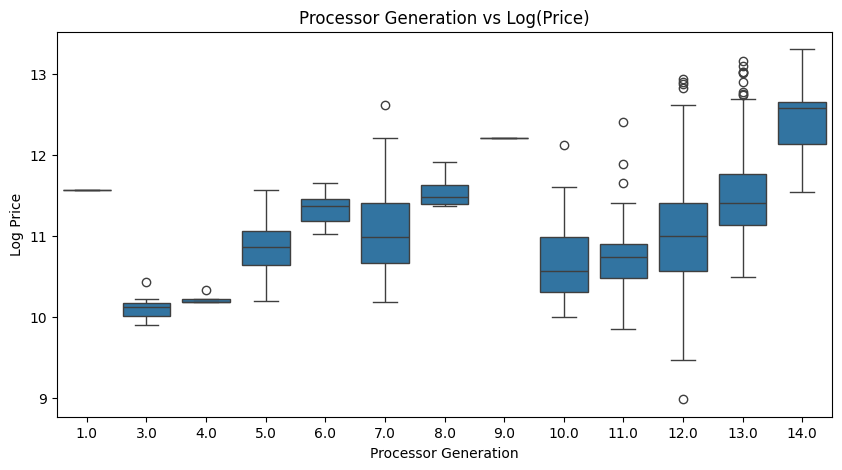

In [114]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Processor_gen'], y=df['Log_Price'])
plt.title("Processor Generation vs Log(Price)")
plt.xlabel("Processor Generation")
plt.ylabel("Log Price")
plt.show()

# Observations:

- Not a perfectly linear relationship — older gens like 7th are priced higher than 11th, likely because 7th gen laptops in this dataset are premium/workstation models
- 1st and 9th gen have only 1 sample each — unreliable, note for feature engineering
- Std is high for 12th and 13th gen — wide price range, meaning generation alone doesn't determine price

#### Note for feature engineering: 
- Processor_gen has a general but non-linear relationship with price. Gens 1 and 9 have single samples and should be flagged. Binning into Legacy (1–7), Mid (8–11), Modern (12–14) may be more effective than using raw generation numbers.

## Display Size

In [115]:
# Distribution
print("Value Counts:")
print(df['Display_size_inches'].value_counts().sort_index())

print(f"\nSkewness: {df['Display_size_inches'].skew():.2f}")
print(df['Display_size_inches'].describe())

Value Counts:
Display_size_inches
11.60     12
12.00      1
12.40      2
13.00      5
13.30     26
13.40      5
13.50      4
13.60      4
14.00    239
14.10      9
14.20      6
14.50      2
15.00      1
15.30      5
15.60    496
15.75      1
16.00    142
16.10     28
16.20      2
17.00      9
17.30     19
18.00      2
Name: count, dtype: int64

Skewness: -0.84
count    1020.000000
mean       15.163775
std         1.001537
min        11.600000
25%        14.000000
50%        15.600000
75%        15.600000
max        18.000000
Name: Display_size_inches, dtype: float64


Observations: 

- Many sizes are very close to each other: 14.0, 14.1, 14.2 - likely same physical size, just different reporting
- Same for 15.6, 15.75 and 16.0, 16.1, 16.2
- Consider binning into standard size categories in feature engineering:

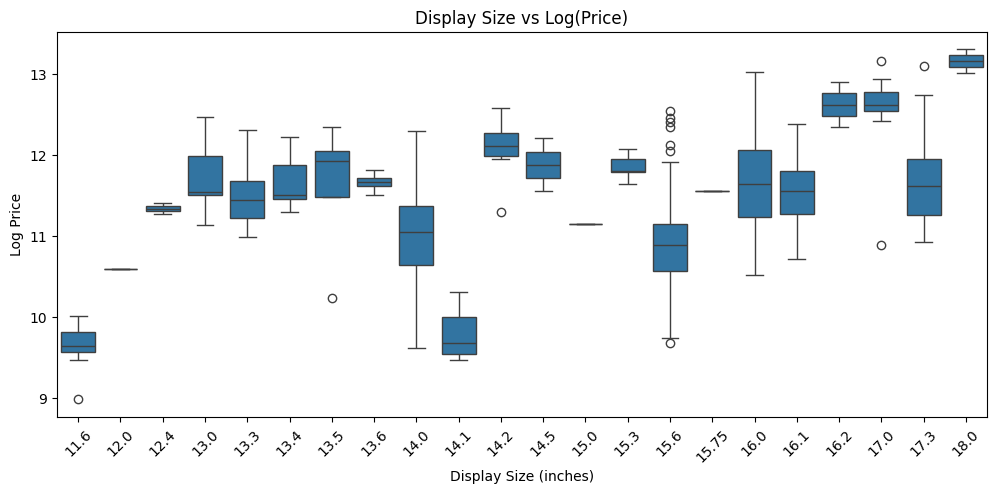

In [116]:
plt.figure(figsize=(12, 5))
sns.boxplot(x=df['Display_size_inches'], y=df['Log_Price'])
plt.title("Display Size vs Log(Price)")
plt.xlabel("Display Size (inches)")
plt.ylabel("Log Price")
plt.xticks(rotation=45)
plt.show()

In [117]:
print(df.groupby('Display_size_inches')['Log_Price'].agg(['mean', 'median', 'std', 'count']).round(2))

                      mean  median   std  count
Display_size_inches                            
11.60                 9.65    9.65  0.27     12
12.00                10.60   10.60   NaN      1
12.40                11.34   11.34  0.09      2
13.00                11.73   11.54  0.51      5
13.30                11.47   11.45  0.31     26
13.40                11.68   11.51  0.37      5
13.50                11.61   11.92  0.94      4
13.60                11.67   11.67  0.12      4
14.00                11.00   11.05  0.52    239
14.10                 9.82    9.68  0.33      9
14.20                12.06   12.11  0.43      6
14.50                11.88   11.88  0.46      2
15.00                11.16   11.16   NaN      1
15.30                11.85   11.80  0.17      5
15.60                10.89   10.89  0.45    496
15.75                11.56   11.56   NaN      1
16.00                11.67   11.65  0.59    142
16.10                11.53   11.56  0.42     28
16.20                12.62   12.62  0.39

# Observation:

- Not a clean linear relationship — 15.6" is cheaper than 14.0" despite being larger, likely because 15.6" is the most common budget/mid-range size
- 14.1" (9 samples, mean 9.82) is suspiciously low — could be budget ultrabooks
- Similar sizes reporting differently (14.0 vs 14.1 vs 14.2) show price variance — confirms binning is necessary

#### Note for feature analysis:
- Display size has a general but non-linear relationship with price. Sizes 14" and 15.6" dominate the dataset and represent budget-to-mid range. 
- Binning into Small/Mid/Large/XLarge categories recommended to reduce noise from near-identical size variations.

## PPI

In [118]:
# distribution
print("Value Counts:")
print(df['ppi'].value_counts().sort_index())

print(f"\nSkewness: {df['ppi'].skew():.2f}")
print(df['ppi'].describe())

Value Counts:
ppi
100.45    17
111.14     3
111.94    22
127.34    14
129.58     1
          ..
266.26     5
266.37     2
267.08     2
283.02     4
337.93     1
Name: count, Length: 62, dtype: int64

Skewness: 1.79
count    1020.000000
mean      157.178265
std        33.585713
min       100.450000
25%       141.210000
50%       141.210000
75%       161.730000
max       337.930000
Name: ppi, dtype: float64


In [119]:
print(df.groupby('ppi')['Log_Price'].agg(['mean', 'median', 'std', 'count']).round(2))

         mean  median   std  count
ppi                               
100.45  10.28   10.22  0.27     17
111.14   9.64    9.68  0.08      3
111.94  10.42   10.24  0.48     22
127.34  11.45   11.40  0.36     14
129.58  10.90   10.90   NaN      1
...       ...     ...   ...    ...
266.26  11.73   11.54  0.51      5
266.37  12.70   12.70  0.11      2
267.08  11.92   11.92  0.04      2
283.02  12.71   12.71  0.17      4
337.93  12.22   12.22   NaN      1

[62 rows x 4 columns]


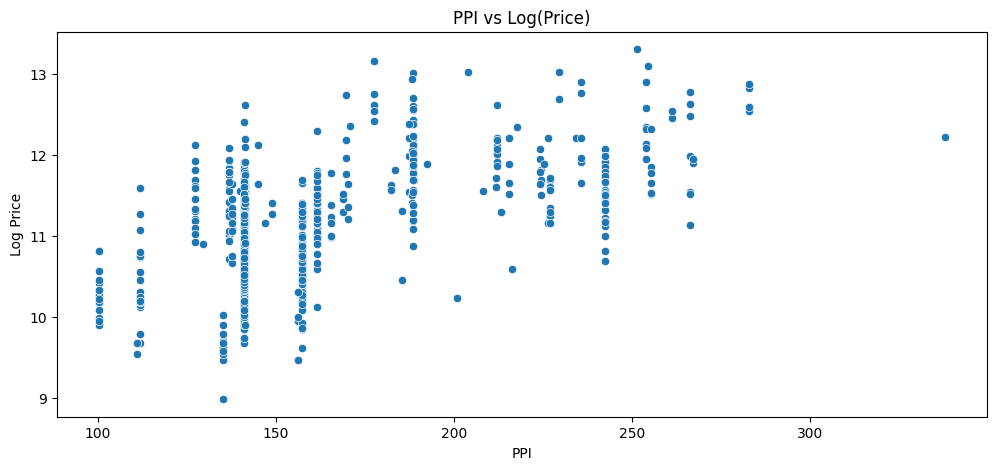

In [120]:
plt.figure(figsize=(12, 5))
sns.scatterplot(x=df['ppi'], y=df['Log_Price'])
plt.title("PPI vs Log(Price)")
plt.xlabel("PPI")
plt.ylabel("Log Price")
plt.show()

In [121]:
print(f"Correlation between ppi and Log_Price: {df['ppi'].corr(df['Log_Price']):.2f}")

Correlation between ppi and Log_Price: 0.58


# Observations:
- Higher ppi displays (retina, 4K) command a price premium
- Not a strong linear relationship (0.58) — ppi alone doesn't determine price, it works together with other specs

#### Note for feature engineering:
- ppi has a moderate positive correlation (0.58) with price. Since ppi is derived from resolution and screen size, Horizontal_pixel and Vertical_pixel are redundant and should be dropped during feature engineering.
- ppi has 62 unique values — we can binn into standard categories (Low, Standard, High, Very High, Ultra) during feature engineering to reduce noise and improve model performance.

# Categorical Variable analysis

## Brand

In [122]:
print("Value Counts:")
print(df['Brand'].value_counts())

print(f"\nUnique brands: {df['Brand'].nunique()}")

Value Counts:
Brand
Lenovo       217
HP           213
Asus         157
Dell         116
MSI           97
Acer          69
Samsung       32
Apple         20
Infinix       20
Chuwi          8
Zebronics      7
Microsoft      7
LG             7
Xiaomi         6
Gigabyte       6
Honor          6
Avita          6
Ultimus        5
Wings          3
Fujitsu        3
Primebook      3
Huawei         2
AXL            2
Jio            1
Ninkear        1
ASUS           1
Walker         1
iBall          1
Tecno          1
Razer          1
Colorful       1
Name: count, dtype: int64

Unique brands: 31


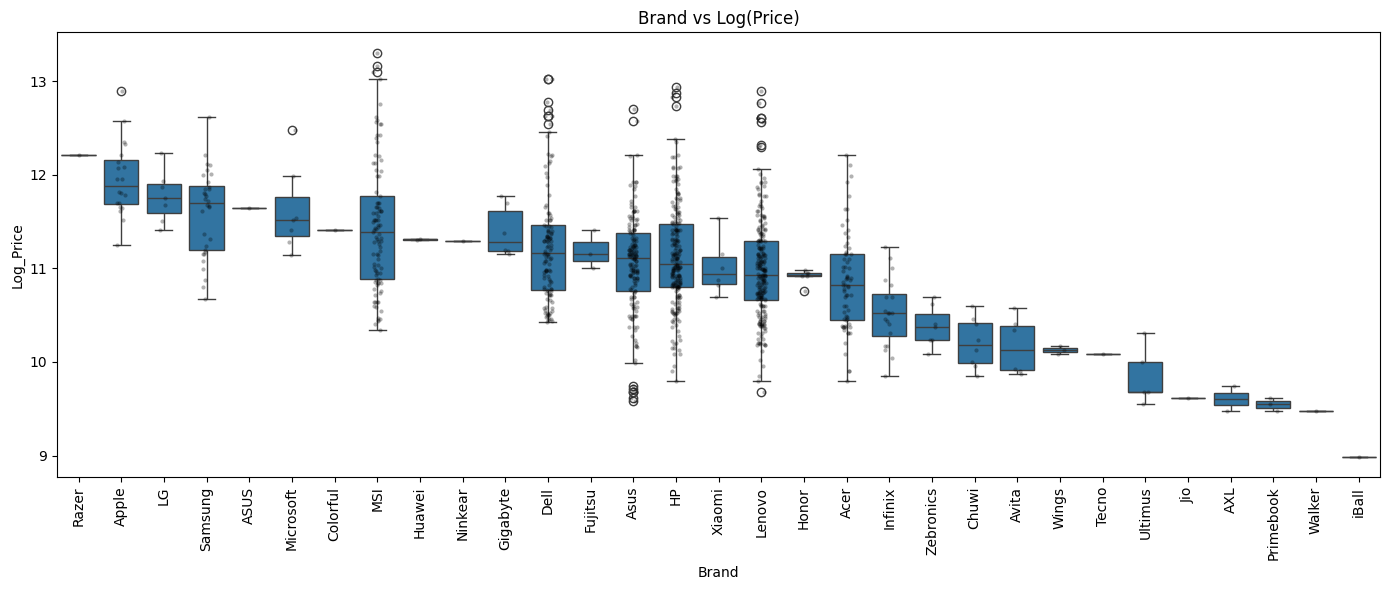

In [123]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='Brand', y='Log_Price', data=df, order=df.groupby('Brand')['Log_Price'].median().sort_values(ascending=False).index)
sns.stripplot(x='Brand', y='Log_Price', data=df, order=df.groupby('Brand')['Log_Price'].median().sort_values(ascending=False).index, color='black', alpha=0.3, size=3)
plt.xticks(rotation=90)
plt.title("Brand vs Log(Price)")
plt.tight_layout()
plt.show()

## Observations:
- Clear brand-based price segmentation 
- Apple, LG, Microsoft command significant premium
- Lenovo and HP are mid-range despite being most common in dataset
- Single sample brands are unreliable for modeling
- ASUS and Asus are the same brand — data quality issue, needs fixing
- Single entry brands (Jio, Ninkear, Walker, iBall, Razer, Colorful) — very few samples, unreliable


#### Note for Feature Engineering:

- Consider creating brand tier feature: Premium / Mid-High / Mid / Budget
- Standardize all brand names to title case using df['Brand'] = df['Brand'].str.strip().str.title() to fix inconsistencies like ASUS vs Asus.
- Group rare brands with very few samples (Jio, Ninkear, Walker, iBall, Razer, Colorful, etc.) into an Other category to reduce noise in modeling.



## Processor Brand

In [124]:
print("Value Counts:")
print(df['Processor_brand'].value_counts())

print(f"\nUnique processor brands: {df['Processor_brand'].nunique()}")

Value Counts:
Processor_brand
Intel        742
AMD          250
Apple         18
MediaTek       7
Qualcomm       1
Microsoft      1
HiSilicon      1
Name: count, dtype: int64

Unique processor brands: 7


                  mean  median   std  count
Processor_brand                            
Qualcomm         12.00   12.00   NaN      1
Apple            11.95   11.88  0.40     18
HiSilicon        11.31   11.31   NaN      1
Intel            11.14   11.11  0.65    742
Microsoft        11.14   11.14   NaN      1
AMD              10.96   10.93  0.47    250
MediaTek          9.70    9.62  0.24      7


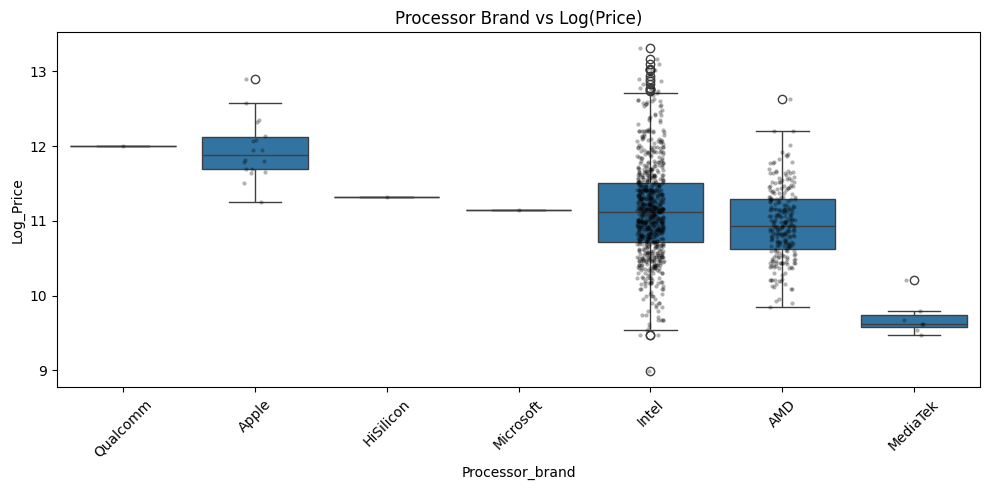

In [125]:
print(df.groupby('Processor_brand')['Log_Price'].agg(['mean', 'median', 'std', 'count']).round(2).sort_values('mean', ascending=False))

plt.figure(figsize=(10, 5))
sns.boxplot(x='Processor_brand', y='Log_Price', data=df, order=df.groupby('Processor_brand')['Log_Price'].median().sort_values(ascending=False).index)
sns.stripplot(x='Processor_brand', y='Log_Price', data=df, order=df.groupby('Processor_brand')['Log_Price'].median().sort_values(ascending=False).index, color='black', alpha=0.3, size=3)
plt.title("Processor Brand vs Log(Price)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observation:
- Clear processor brand price segmentation 
- Apple chips significantly more expensive than Intel/AMD
- Intel vs AMD difference is small (0.18) — not a strong differentiator
- MediaTek clearly budget segment

#### Note for feature engineering:
- Group Qualcomm, Microsoft, HiSilicon (1 sample each) into Other category. 
- Create processor tier feature: Premium(Apple) / Standard(Intel, AMD) / Budget(MediaTek, Other)

## Storage type

In [126]:
print("Value Counts:")
print(df['Storage_type'].value_counts())

print(f"\nUnique storage types: {df['Storage_type'].nunique()}")

Value Counts:
Storage_type
 SSD               999
 Hard Disk          14
Hard Disk & SSD      6
 NVMe SSD            1
Name: count, dtype: int64

Unique storage types: 4


In [127]:
print(df['Storage_type'].unique())

[' SSD' 'Hard Disk & SSD' ' NVMe SSD' ' Hard Disk']


                  mean  median   std  count
Storage_type                               
 SSD             11.12   11.08  0.62    999
Hard Disk & SSD  11.04   10.96  0.32      6
 NVMe SSD        10.80   10.80   NaN      1
 Hard Disk        9.81    9.77  0.38     14


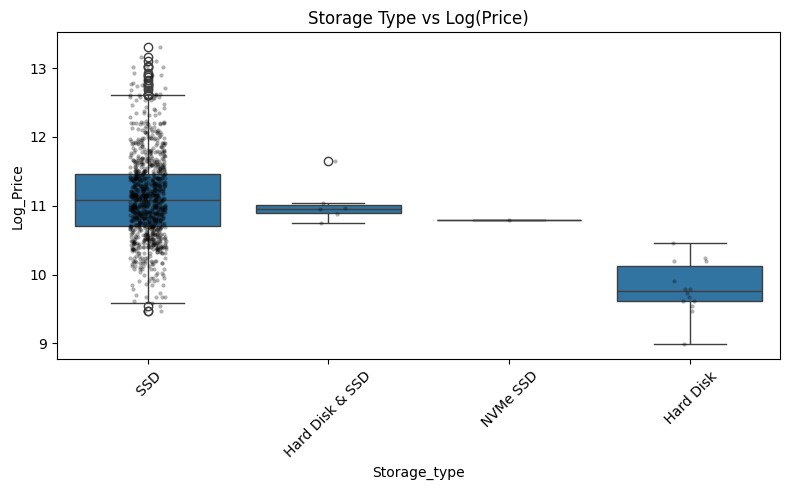

In [128]:
print(df.groupby('Storage_type')['Log_Price'].agg(['mean', 'median', 'std', 'count']).round(2).sort_values('mean', ascending=False))

plt.figure(figsize=(8, 5))
sns.boxplot(x='Storage_type', y='Log_Price', data=df, order=df.groupby('Storage_type')['Log_Price'].median().sort_values(ascending=False).index)
sns.stripplot(x='Storage_type', y='Log_Price', data=df, order=df.groupby('Storage_type')['Log_Price'].median().sort_values(ascending=False).index, color='black', alpha=0.3, size=3)
plt.title("Storage Type vs Log(Price)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observations:
- SSD clearly dominates both in count (97.9%) and price
- Hard Disk laptops are significantly cheaper — budget/legacy segment
- NVMe SSD and Hard Disk & SSD have too few samples to be reliable
- Storage type alone is not a strong price differentiator since 97.9% are SSD

#### Note for feature engineering:
- Strip leading spaces from all values
- Merge NVMe SSD into SSD
- Storage type may have low feature importance in modeling due to 97.9% being SSD — consider dropping if model confirms low importance via SHAP values

## Graphics brand

In [129]:
print("Value Counts:")
print(df['Graphics_brand'].value_counts())

print(f"\nUnique graphics brands: {df['Graphics_brand'].nunique()}")

Value Counts:
Graphics_brand
Intel     488
NVIDIA    354
AMD       151
Apple      18
ARM         7
Adreno      1
Radeon      1
Name: count, dtype: int64

Unique graphics brands: 7


In [130]:
print(df[df['Graphics_brand'] == 'Radeon'][['Name', 'Graphics_brand', 'Graphics_name']])

                                                  Name Graphics_brand  \
587  Apple MacBook Pro 16 Laptop (9th Gen Core i9/ ...         Radeon   

        Graphics_name  
587  Radeon Pro 5500M  


                 mean  median   std  count
Graphics_brand                            
Radeon          12.21   12.21   NaN      1
Apple           11.95   11.88  0.40     18
NVIDIA          11.51   11.41  0.54    354
Adreno          11.14   11.14   NaN      1
Intel           10.90   10.90  0.56    488
AMD             10.71   10.69  0.37    151
ARM              9.70    9.62  0.24      7


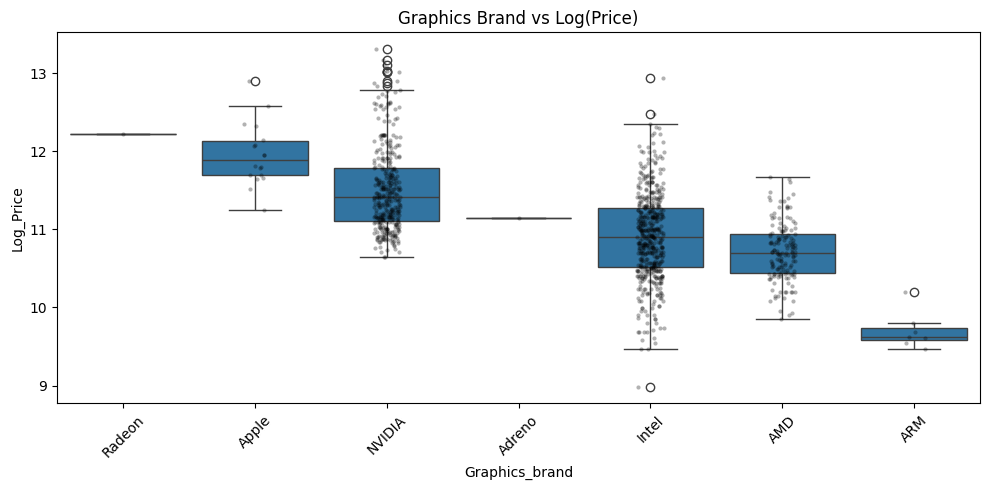

In [131]:
print(df.groupby('Graphics_brand')['Log_Price'].agg(['mean', 'median', 'std', 'count']).round(2).sort_values('mean', ascending=False))

plt.figure(figsize=(10, 5))
sns.boxplot(x='Graphics_brand', y='Log_Price', data=df, order=df.groupby('Graphics_brand')['Log_Price'].median().sort_values(ascending=False).index)
sns.stripplot(x='Graphics_brand', y='Log_Price', data=df, order=df.groupby('Graphics_brand')['Log_Price'].median().sort_values(ascending=False).index, color='black', alpha=0.3, size=3)
plt.title("Graphics Brand vs Log(Price)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observations:
- Apple highest (mean = 11.95) — premium integrated GPU
- NVIDIA second (mean = 11.51) — dedicated GPU commands significant premium
- Intel integrated GPUs mid-range (mean = 10.90) — common in everyday laptops
- AMD GPUs cheaper than Intel (mean = 10.71) despite being dedicated in some cases
- ARM lowest (mean = 9.70) — budget/mobile chips
- Radeon and Adreno have 1 sample each — unreliable

#### Note for Feature Engineering:
- Merge `Radeon` into `AMD`
- Group `Adreno` into `Other` — 1 sample, not representative
- Consider creating GPU tier feature: Premium(Apple, NVIDIA) / Standard(Intel, AMD) / Budget(ARM, Other)


## Graphics name

In [132]:
print("Value Counts:")
print(df['Graphics_name'].value_counts().head(20))

print(f"\nUnique graphics names: {df['Graphics_name'].nunique()}")

Value Counts:
Graphics_name
Intel Iris Xe Graphics               100
Intel UHD Graphics                    84
NVIDIA GeForce RTX 3050               75
Intel Integrated Iris Xe              67
Intel Integrated UHD                  62
NVIDIA GeForce RTX 2050               56
NVIDIA GeForce RTX 4060               53
NVIDIA GeForce RTX 4050               49
AMD Radeon AMD                        47
AMD Radeon Graphics                   42
Intel Integrated UHD Graphics         21
Intel Arc Graphics                    21
NVIDIA GeForce GTX 1650               21
NVIDIA GeForce RTX 4070               18
Integrated Intel Iris Xe Graphics     18
Integrated Intel UHD Graphics         13
Intel Iris Xe                         12
AMD Radeon                            11
Intel Integrated                      10
Intel Graphics                        10
Name: count, dtype: int64

Unique graphics names: 137


In [133]:
print(df['Graphics_name'].value_counts().tail(20))

Graphics_name
Intel ARC Graphics                     1
Intel Integrated Intel UHD Graphics    1
AMD Radeon  RX 7600S                   1
Integrated Intel iris Xe Graphics      1
Intel Integrated Iris Xe Graphics      1
NVIDIA Geforce GTX1650 Max Q           1
AMD Radeon Vega 7 Graphics             1
Intel Integrated INTEL UHD             1
Nvidia GeForce RTX 2050                1
NVIDIA GeForce MX570                   1
NVIDIA Geforce RTX 2050                1
AMD Radeon 680M                        1
AMD Radeon AMD Radeon RX 6500M         1
NVIDIA GeForce GTX 1650 Max Q          1
30 Core GPU                            1
Arm Mali-G72 MP3 Graphics              1
Intel Integrated ARC A530M             1
Intel Integrated ARC Graphics          1
Intel HD                               1
NVIDIA GEFORCE RTX 4050                1
Name: count, dtype: int64


                                    mean  median   std  count
Graphics_name                                                
NVIDIA GeForce RTX 3500 Ada        13.16   13.16   NaN      1
Nvidia GeForce RTX4080             13.10   13.10   NaN      1
NVIDIA RTX 3000 Ada                13.02   13.02   NaN      1
40 Core GPU                        12.90   12.90   NaN      1
NVIDIA GeForce RTX 3080 Ti         12.85   12.85  0.03      2
NVIDIA GeForce RTX 4090            12.81   12.77  0.34      9
NVIDIA GEFORCE RTX 4080            12.62   12.62   NaN      1
NVIDIA GeForce RTX 4080            12.60   12.58  0.06      5
NVIDIA Geforce RTX 4080            12.59   12.60  0.02      3
30 Core GPU                        12.58   12.58   NaN      1
NVIDIA RTX 4050                    12.50   12.50  0.06      2
NVIDIA GEFORCE RTX 3060            12.41   12.41   NaN      1
18 Core GPU                        12.34   12.34  0.02      2
Intel Iris Xe Integrated Graphics  12.31   12.31   NaN      1
NVIDIA G

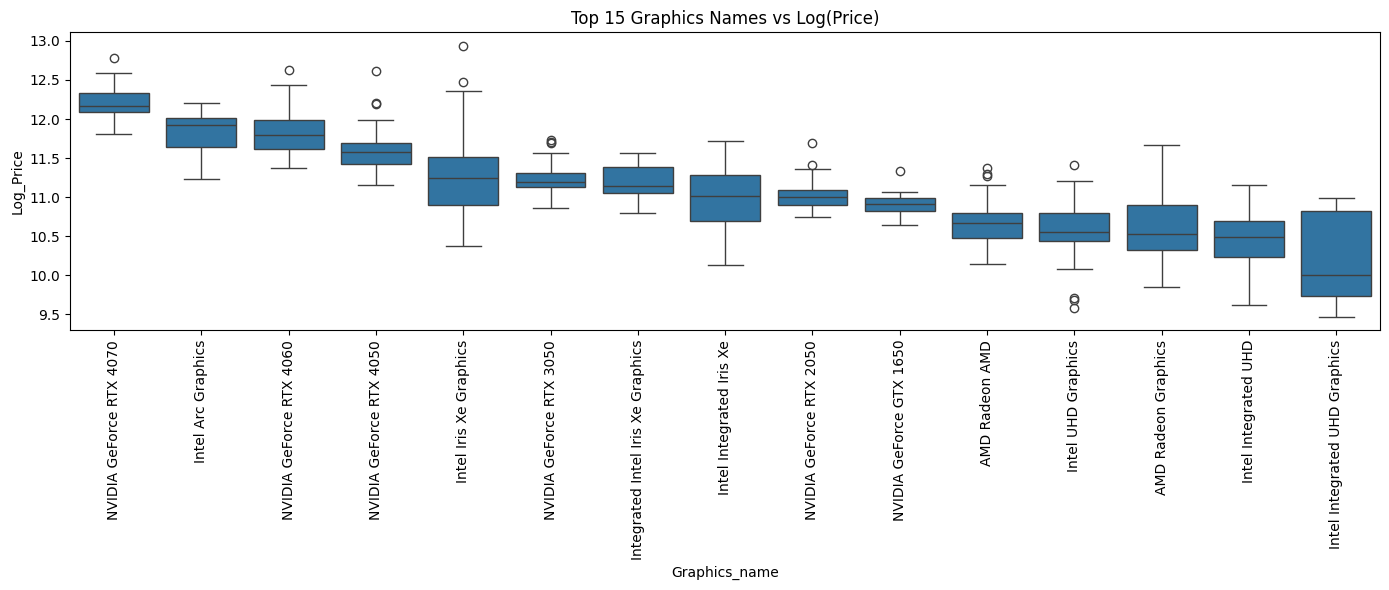

In [134]:
#Selecting only top 15 since 137 would not be readable
print(df.groupby('Graphics_name')['Log_Price'].agg(['mean', 'median', 'std', 'count']).round(2).sort_values('mean', ascending=False).head(20))

plt.figure(figsize=(14, 6))
top_graphics = df['Graphics_name'].value_counts().head(15).index
sns.boxplot(x='Graphics_name', y='Log_Price', data=df[df['Graphics_name'].isin(top_graphics)], order=df[df['Graphics_name'].isin(top_graphics)].groupby('Graphics_name')['Log_Price'].median().sort_values(ascending=False).index)
plt.xticks(rotation=90)
plt.title("Top 15 Graphics Names vs Log(Price)")
plt.tight_layout()
plt.show()

## Observations:
- NVIDIA GPUs (RTX 4090, 4080, 4070) have the highest laptop prices 
- Apple GPU cores (40 Core, 30 Core, 18 Core, 14 Core) are priced in the premium tier alongside high-end NVIDIA GPUs
- Many single-sample entries at the top (RTX 3500 Ada, RTX 4080 variants) — unreliable individually but confirm premium pricing trend
- Inconsistencies: `NVIDIA GeForce RTX 4080`, `NVIDIA GEFORCE RTX 4080`, `Nvidia GeForce RTX4080` — all same GPU
- `Radeon Pro 5500M` appearing separately instead of under AMD — confirms naming inconsistency noted earlier

#### Note for Feature Engineering:
- Standardize casing and strip whitespace
- Consolidate duplicate names referring to same GPU
- Extract GPU tier instead of using exact name: Integrated / GTX / RTX 3000 / RTX 4000 / Apple Silicon
- Fix Apple GPU names (14/18/30/40 Core GPU) → `Apple Integrated`
- `Graphics_name` has high cardinality (137 values) — likely to be replaced by GPU tier feature, confirm via SHAP values after modeling

## Graphics Integrated

In [135]:
print("Value Counts:")
print(df['Graphics_integreted'].value_counts())

print(f"\nUnique values: {df['Graphics_integreted'].nunique()}")

Value Counts:
Graphics_integreted
False    774
True     246
Name: count, dtype: int64

Unique values: 2


                            mean  median   std  count
Graphics_integreted_label                            
Dedicated                  11.20   11.16  0.63    774
Integrated                 10.77   10.80  0.51    246


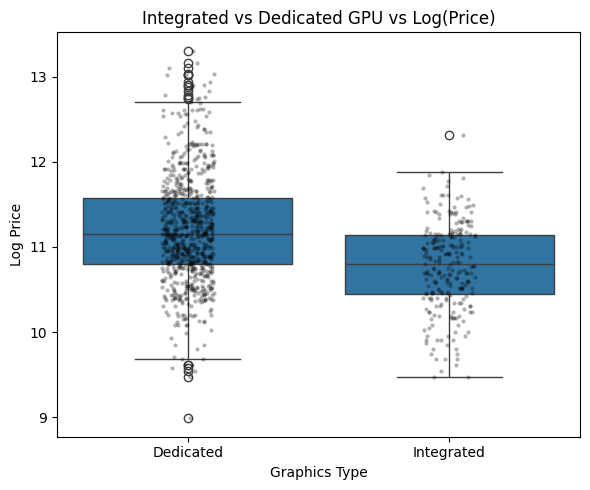

In [136]:
# Map True/False to meaningful labels for visualization
df['Graphics_integreted_label'] = df['Graphics_integreted'].map({True: 'Integrated', False: 'Dedicated'})

print(df.groupby('Graphics_integreted_label')['Log_Price'].agg(['mean', 'median', 'std', 'count']).round(2))

plt.figure(figsize=(6, 5))
sns.boxplot(x='Graphics_integreted_label', y='Log_Price', data=df)
sns.stripplot(x='Graphics_integreted_label', y='Log_Price', data=df, color='black', alpha=0.3, size=3)
plt.title("Integrated vs Dedicated GPU vs Log(Price)")
plt.xlabel("Graphics Type")
plt.ylabel("Log Price")
plt.tight_layout()
plt.show()

## Observations:
- Dedicated GPUs have a higher average price (11.20) compared to Integrated (10.77) 
- Dedicated GPUs show wider price spread — ranges from budget dedicated GPUs all the way to high-end gaming GPUs
- Integrated GPUs are more consistently priced (std = 0.51) — typically found in everyday productivity laptops
- 75.9% of dataset has dedicated GPU — dataset leans slightly toward gaming/performance laptops

#### Note for Feature Engineering:
- Clean binary feature — encode directly as 0/1 for modeling
- Drop the temporary `Graphics_integreted_label` column after EDA
- May be correlated with `Graphics_brand` and `Graphics_name` — check multicollinearity during modeling

## RAM Type

In [137]:
print("Value Counts:")
print(df['RAM_type'].value_counts())

print(f"\nUnique values: {df['RAM_type'].nunique()}")

Value Counts:
RAM_type
DDR4       544
DDR5       188
LPDDR5     173
LPDDR4X     53
LPDDR5X     38
LPDDR4      16
DDR3         2
LPDDRX4      2
Unified      1
DDR6         1
LPDDR3       1
PDDR5X       1
Name: count, dtype: int64

Unique values: 12


In [138]:
print(df[df['RAM_type'] == 'LPDDRX4'][['Name', 'RAM_type', 'RAM_GB']].head())
print(df[df['RAM_type'] == 'PDDR5X'][['Name', 'RAM_type', 'RAM_GB']].head())
print(df[df['RAM_type'] == 'Unified'][['Name', 'RAM_type', 'RAM_GB']].head())

                                                  Name RAM_type  RAM_GB
302  Honor MagicBook X14 Pro 2024 ‎FRI-G56 Laptop (...  LPDDRX4      16
591  Honor MagicBook X14 Pro 2024 FRI-G58 Laptop (1...  LPDDRX4       8
                                                  Name RAM_type  RAM_GB
866  Lenovo Yoga Book 9i 2023 82YQ001DIN Laptop (13...   PDDR5X      16
                                                  Name RAM_type  RAM_GB
138  Apple MacBook Air 2022 Laptop (Apple M2/ 8GB/ ...  Unified       8


           mean  median   std  count
RAM_type                            
PDDR5X    12.31   12.31   NaN      1
DDR5      11.73   11.64  0.54    188
LPDDR5X   11.71   11.82  0.42     38
Unified   11.69   11.69   NaN      1
LPDDR5    11.20   11.21  0.57    173
DDR6      11.10   11.10   NaN      1
LPDDRX4   10.93   10.93  0.03      2
DDR4      10.87   10.88  0.46    544
LPDDR4X   10.74   10.69  0.66     53
LPDDR3    10.60   10.60   NaN      1
LPDDR4    10.21   10.13  0.52     16
DDR3       9.42    9.42  0.61      2


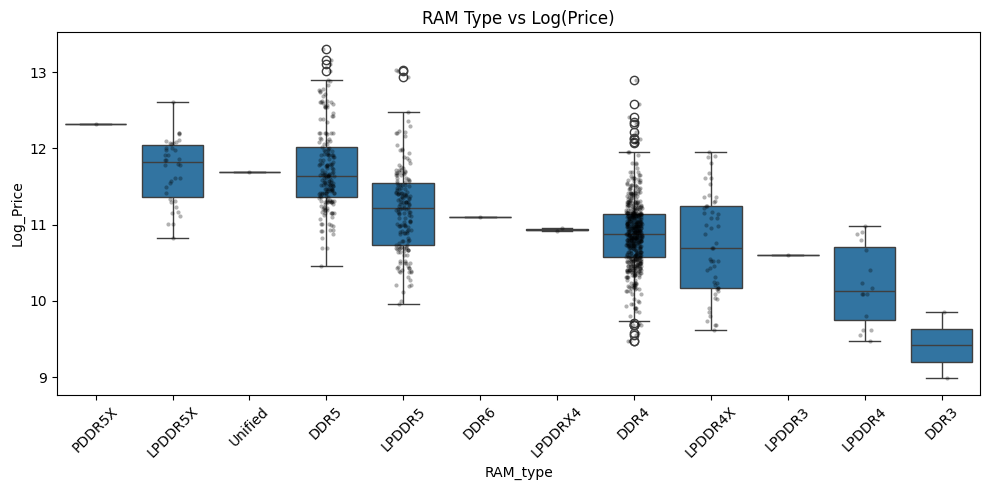

In [139]:
print(df.groupby('RAM_type')['Log_Price'].agg(['mean', 'median', 'std', 'count']).round(2).sort_values('mean', ascending=False))

plt.figure(figsize=(10, 5))
sns.boxplot(x='RAM_type', y='Log_Price', data=df, order=df.groupby('RAM_type')['Log_Price'].median().sort_values(ascending=False).index)
sns.stripplot(x='RAM_type', y='Log_Price', data=df, order=df.groupby('RAM_type')['Log_Price'].median().sort_values(ascending=False).index, color='black', alpha=0.3, size=3)
plt.title("RAM Type vs Log(Price)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observations:
- Clear generational pricing trend — newer RAM types (DDR5, LPDDR5X) are more expensive, older types (DDR3, LPDDR4) are cheaper
- DDR4 dominates the dataset (53.3%) at mid-lower price range (10.87) — current mainstream standard
- Apple Unified memory (11.69) prices similarly to DDR5 despite only 1 sample
- Several entries (PDDR5X, DDR6, LPDDR3) have only 1 sample — unreliable

#### Note for Feature Engineering:
- Fix typos: `LPDDRX4` → `LPDDR4X`, `PDDR5X` → `LPDDR5X`
- Group `DDR3`, `LPDDR3`, `DDR6` into `Other`
- Consider RAM generation tier: Legacy / Standard / Modern / Premium

## Operating system

In [140]:
print("Value Counts:")
print(df['Operating_system'].value_counts())

print(f"\nUnique values: {df['Operating_system'].nunique()}")

Value Counts:
Operating_system
Windows 11 OS       943
Mac OS               18
Windows 10 OS        17
DOS OS               16
Chrome OS            15
Ubuntu OS             3
Prime OS              2
jio                   1
DOS 3.0 OS            1
Android 11 OS         1
Mac 10.15.3\t OS      1
Mac Catalina OS       1
Linux OS              1
Name: count, dtype: int64

Unique values: 13


In [141]:
print(df[df['Operating_system'] == 'jio'][['Name', 'Operating_system']].head())
print(df[df['Operating_system'] == 'Mac 10.15.3\t OS'][['Name', 'Operating_system']].head())
print(df[df['Operating_system'] == 'Mac Catalina OS'][['Name', 'Operating_system']].head())

                                                  Name Operating_system
344  Jio JioBook Cloud Laptop (Octa Core/ 4GB/ 64GB...              jio
                                                  Name  Operating_system
585  Apple MacBook Air 2020 Laptop (10th Gen Core i...  Mac 10.15.3\t OS
                                                  Name Operating_system
587  Apple MacBook Pro 16 Laptop (9th Gen Core i9/ ...  Mac Catalina OS


                   mean  median   std  count
Operating_system                            
Mac Catalina OS   12.21   12.21   NaN      1
Mac OS            11.95   11.88  0.40     18
Mac 10.15.3\t OS  11.61   11.61   NaN      1
Linux OS          11.31   11.31   NaN      1
Windows 11 OS     11.12   11.08  0.60    943
Windows 10 OS     11.03   11.14  0.74     17
Ubuntu OS         10.60   10.56  0.16      3
DOS OS            10.45   10.42  0.35     16
DOS 3.0 OS        10.09   10.09   NaN      1
Chrome OS         10.03   10.02  0.33     15
Android 11 OS      9.62    9.62   NaN      1
jio                9.62    9.62   NaN      1
Prime OS           9.51    9.51  0.05      2


/var/folders/8j/w4cf450n1sscq6nksr6976b40000gn/T/ipykernel_12348/1817597181.py:8: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/mgmanjusha/Documents/NEU/Spring_26/FAI/Final Project/Machine-Learning-Based-Price-Fairness-Analysis-for-Laptop-E-Commerce/venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


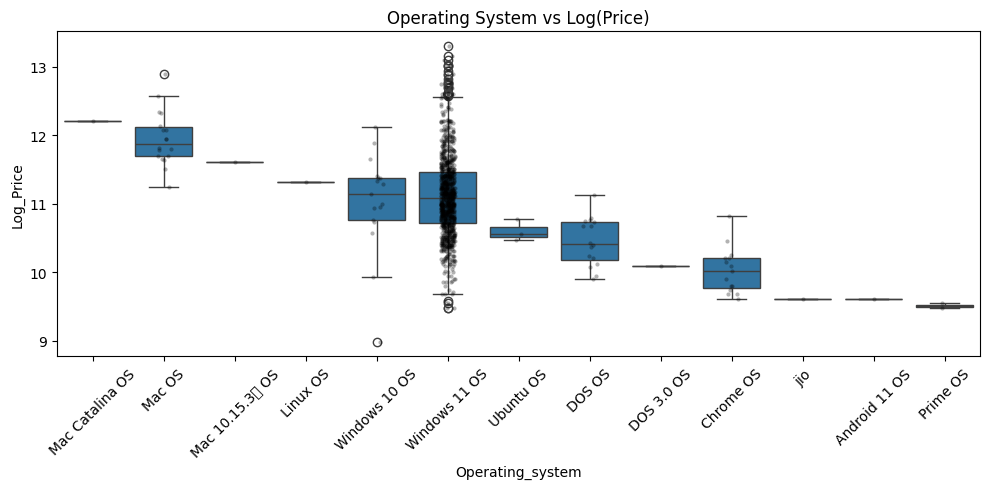

In [142]:
print(df.groupby('Operating_system')['Log_Price'].agg(['mean', 'median', 'std', 'count']).round(2).sort_values('mean', ascending=False))

plt.figure(figsize=(10, 5))
sns.boxplot(x='Operating_system', y='Log_Price', data=df, order=df.groupby('Operating_system')['Log_Price'].median().sort_values(ascending=False).index)
sns.stripplot(x='Operating_system', y='Log_Price', data=df, order=df.groupby('Operating_system')['Log_Price'].median().sort_values(ascending=False).index, color='black', alpha=0.3, size=3)
plt.title("Operating System vs Log(Price)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observations:
- Mac OS commands the highest reliable price (11.95) — Apple premium 
- Windows 11 dominates dataset (92.4%) at mid-range price (11.12) — mainstream standard
- DOS OS is notably cheap (10.45) — typically found in budget laptops sold without a proper OS
- Chrome OS is the cheapest reliable category (10.03) — budget/education segment
- Mac Catalina, Mac 10.15.3, Linux, DOS 3.0, Android, jio, Prime OS all have 1-3 samples — unreliable

#### Note for Feature Engineering:
- Strip tab characters and whitespace from all OS names
- Merge `Mac Catalina OS`, `Mac 10.15.3\t OS` → `Mac OS`
- Merge `DOS OS`, `DOS 3.0 OS` → `DOS OS`
- Group `Ubuntu OS`, `Prime OS`, `Android 11 OS`, `Linux OS`, `jio` into `Other`

## Touch Screen

In [143]:
print("Value Counts:")
print(df['Touch_screen'].value_counts())

print(f"\nUnique values: {df['Touch_screen'].nunique()}")

Value Counts:
Touch_screen
False    904
True     116
Name: count, dtype: int64

Unique values: 2


               mean  median   std  count
Touch_screen                            
False         11.04   11.00  0.62    904
True          11.53   11.48  0.54    116


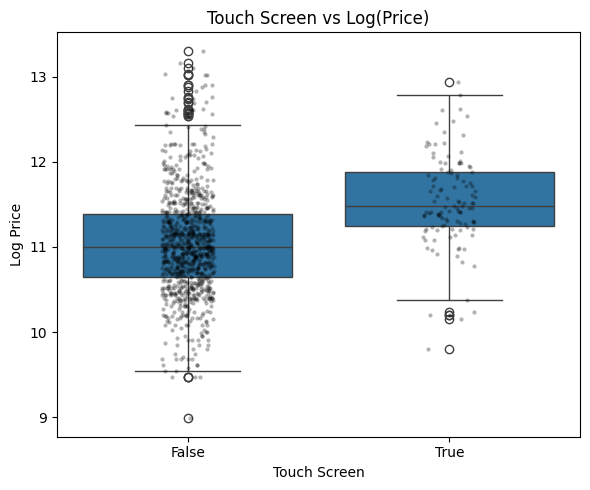

In [144]:
print(df.groupby('Touch_screen')['Log_Price'].agg(['mean', 'median', 'std', 'count']).round(2))

plt.figure(figsize=(6, 5))
sns.boxplot(x='Touch_screen', y='Log_Price', data=df)
sns.stripplot(x='Touch_screen', y='Log_Price', data=df, color='black', alpha=0.3, size=3)
plt.title("Touch Screen vs Log(Price)")
plt.xlabel("Touch Screen")
plt.ylabel("Log Price")
plt.tight_layout()
plt.show()

## Observations:
- Touchscreen laptops are priced higher (11.53) than non-touchscreen (11.04) — premium feature 
- Price gap of 0.49 in log scale — meaningful difference
- Non-touchscreen dominates dataset (88.6%) — touchscreen is still a niche feature
- Both categories have similar spread (std 0.62 vs 0.54) — consistent pricing within each group

#### Note for Feature Engineering:
- Clean binary feature — encode directly as 0/1 for modeling
- No cleaning needed

## Correlation analysis

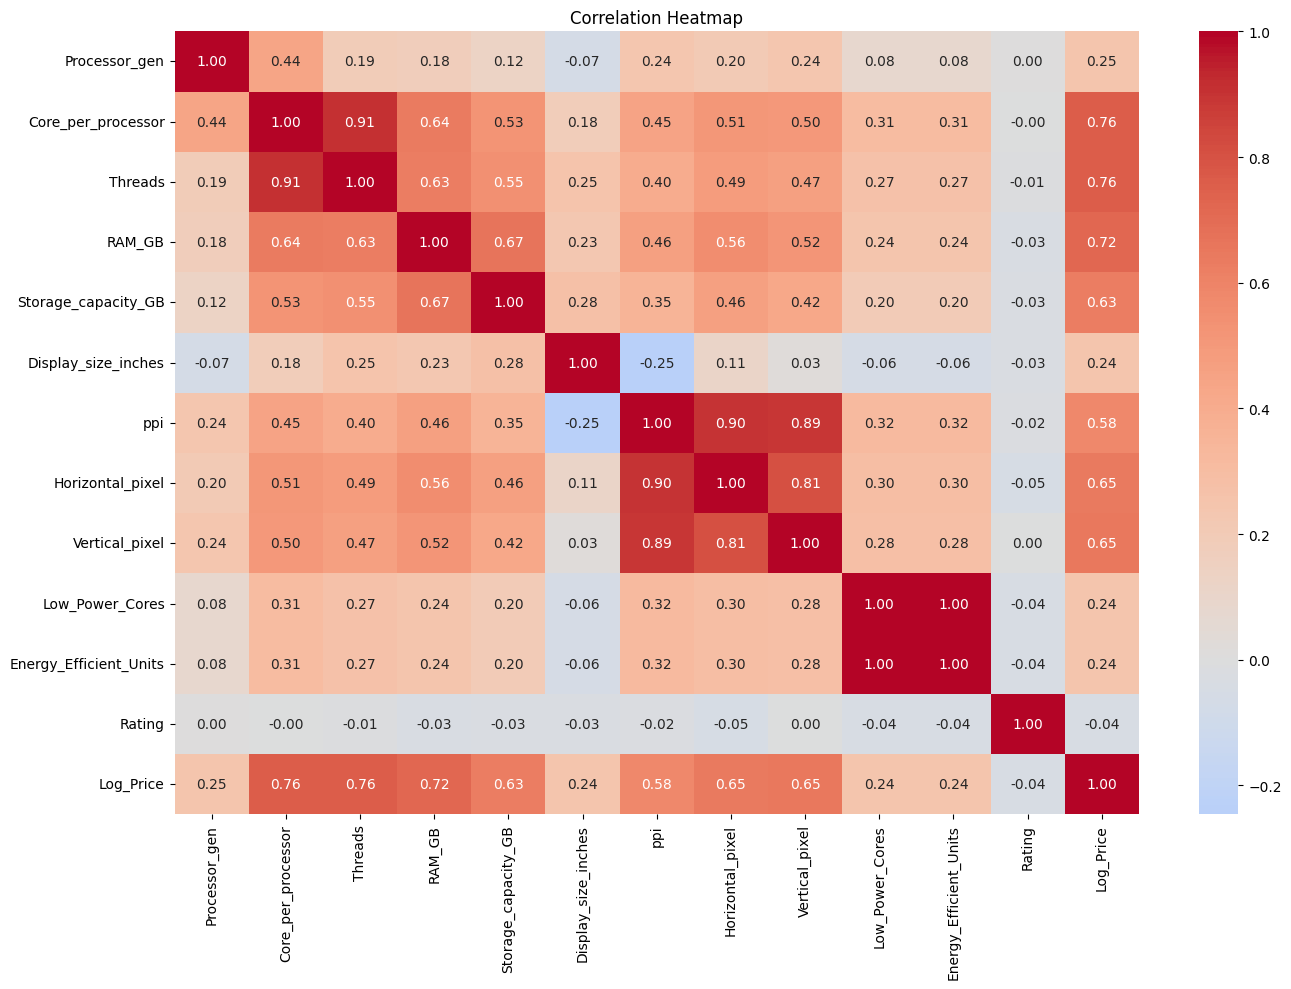

Log_Price                 1.000000
Threads                   0.764712
Core_per_processor        0.759709
RAM_GB                    0.723539
Vertical_pixel            0.653696
Horizontal_pixel          0.649340
Storage_capacity_GB       0.628872
ppi                       0.579940
Processor_gen             0.245970
Low_Power_Cores           0.244353
Energy_Efficient_Units    0.244353
Display_size_inches       0.241734
Rating                   -0.042381
Name: Log_Price, dtype: float64


In [146]:
# Select only numeric columns
corr_cols = ['Processor_gen', 'Core_per_processor', 'Threads', 'RAM_GB', 
             'Storage_capacity_GB', 'Display_size_inches', 'ppi', 
             'Horizontal_pixel', 'Vertical_pixel', 'Low_Power_Cores', 
             'Energy_Efficient_Units', 'Rating', 'Log_Price']

plt.figure(figsize=(14, 10))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Print correlation with Log_Price specifically
print(df[corr_cols].corr()['Log_Price'].sort_values(ascending=False))

## Correlation Heatmap — Final Conclusions

## Observations:
- `Threads` (0.76), `Core_per_processor` (0.76), `RAM_GB` (0.72) are the strongest price drivers 
- `Storage_capacity_GB` (0.64), `Vertical_pixel` (0.65), `Horizontal_pixel` (0.65) show strong correlation
- `ppi` (0.58) moderate correlation — display quality matters but not the strongest driver
- `Processor_gen` (0.25) and `Display_size_inches` (0.24) surprisingly weak
- `Rating` (-0.04) — no relationship with price at all
- `Threads` and `Core_per_processor` are multicollinear — expected since threads = cores × 2
- `Horizontal_pixel` and `Vertical_pixel` are redundant with `ppi`

#### Note for Feature Engineering:
- Drop `Horizontal_pixel`, `Vertical_pixel` — redundant with `ppi`
- Drop `Rating` — near zero correlation with price
- Keep only one of `Threads` or `Core_per_processor` to avoid multicollinearity
- `Low_Power_Cores` and `Energy_Efficient_Units` likely to be dropped — confirm via SHAP

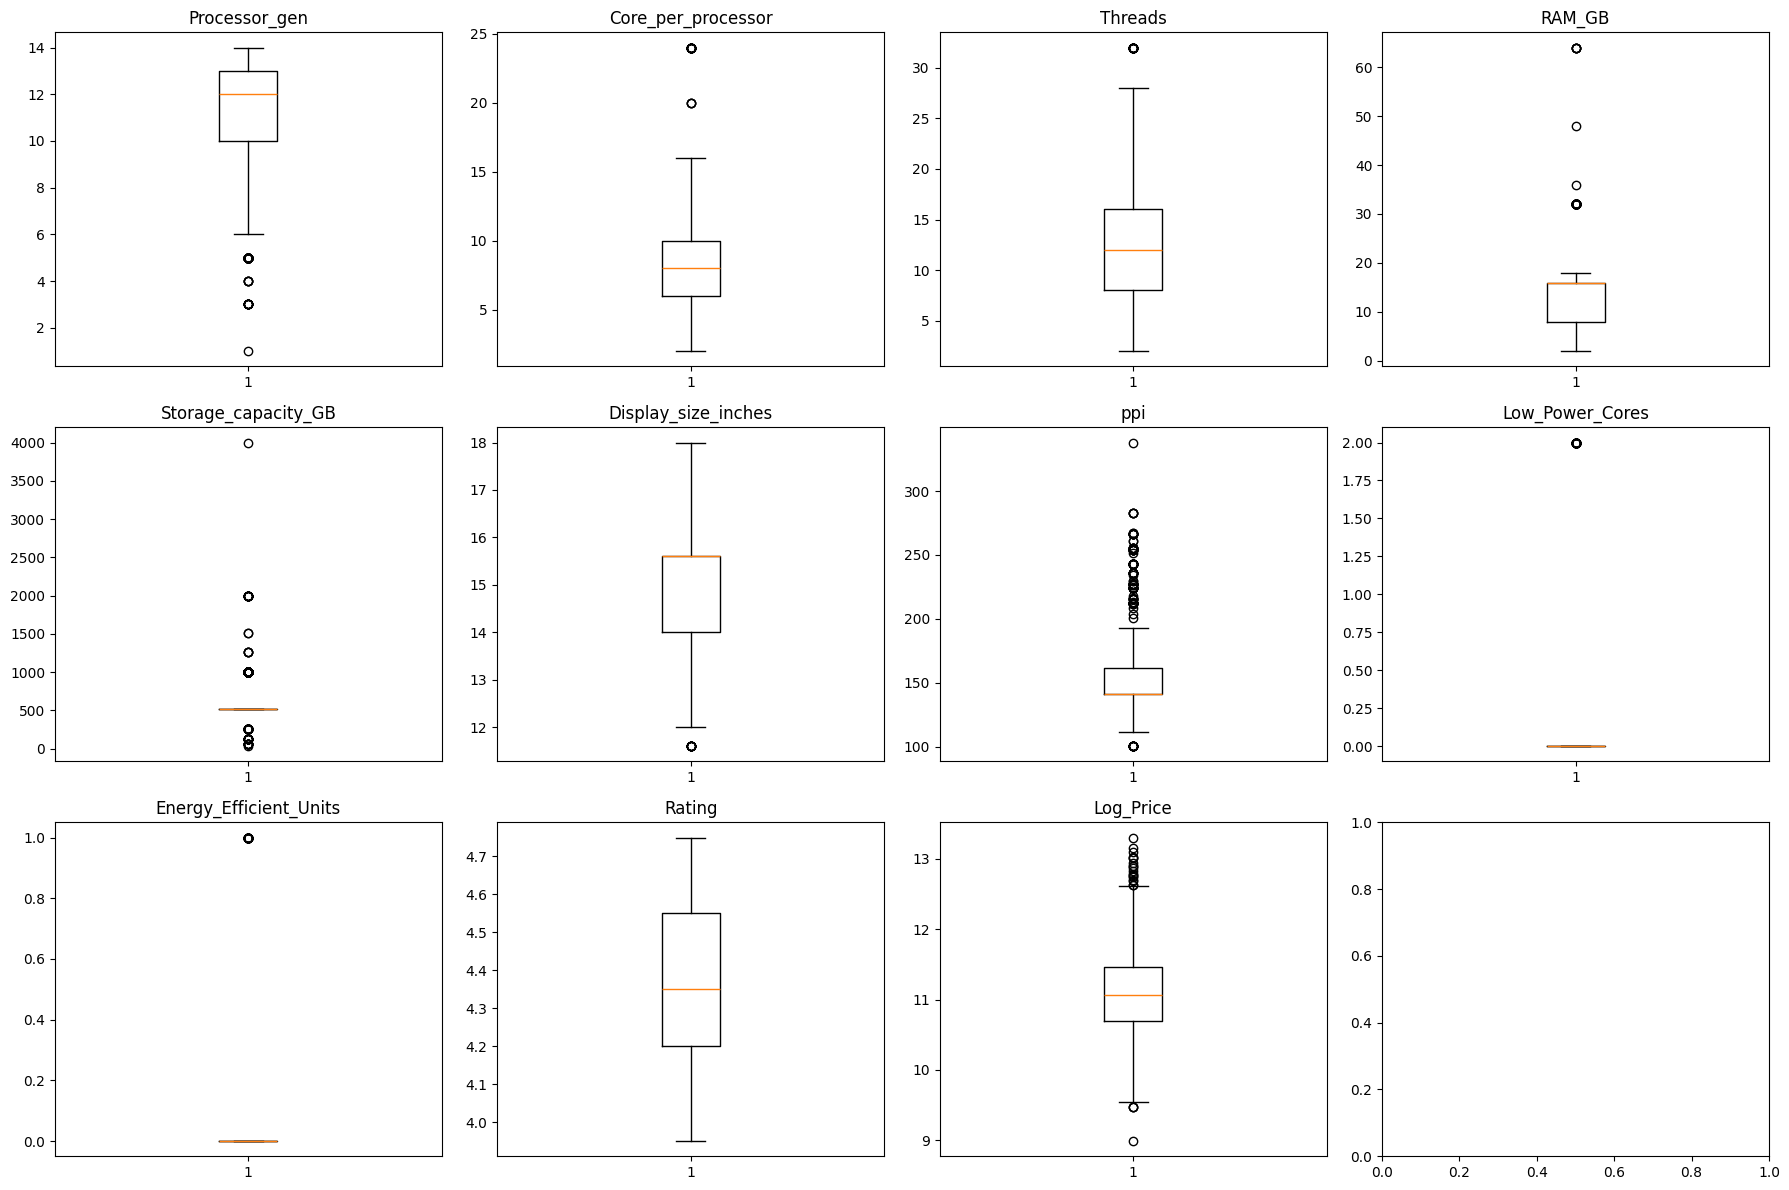

Outlier counts per column:
Processor_gen: 108 (10.6%)
Core_per_processor: 27 (2.6%)
Threads: 23 (2.3%)
RAM_GB: 69 (6.8%)
Storage_capacity_GB: 318 (31.2%)
Display_size_inches: 12 (1.2%)
ppi: 132 (12.9%)
Low_Power_Cores: 44 (4.3%)
Energy_Efficient_Units: 44 (4.3%)
Rating: 0 (0.0%)
Log_Price: 23 (2.3%)


In [147]:
# Boxplots for all numeric columns
corr_cols = ['Processor_gen', 'Core_per_processor', 'Threads', 'RAM_GB', 
             'Storage_capacity_GB', 'Display_size_inches', 'ppi', 
             'Low_Power_Cores', 'Energy_Efficient_Units', 'Rating', 'Log_Price']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(corr_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# IQR method — count outliers per column
print("Outlier counts per column:")
for col in corr_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

## Observations:
- Most outliers are **genuine products**, not data errors — high-end workstations, old-gen budget laptops, high-res displays
- `Storage_capacity_GB` high outlier count is expected due to 512GB domination — will be resolved by binning in feature engineering

#### Note for Feature Engineering:
- Do not blindly drop outliers — most are legitimate products
- Binning `RAM_GB`, `Storage_capacity_GB`, `Processor_gen` will naturally handle outlier impact
- Consider robust scaling (e.g. `RobustScaler`) during modeling to minimize outlier influence

## Categorical variables

In [148]:
cat_cols = ['Brand', 'Processor_brand', 'Processor_variant', 'RAM_type', 
            'Storage_type', 'Graphics_name', 'Graphics_brand', 
            'Graphics_integreted', 'Operating_system', 'Touch_screen']

for col in cat_cols:
    counts = df[col].value_counts()
    rare = counts[counts < 10]
    print(f"\n{col} — {len(rare)} rare categories (< 10 samples):")
    print(rare)


Brand — 22 rare categories (< 10 samples):
Brand
Chuwi        8
Zebronics    7
Microsoft    7
LG           7
Xiaomi       6
Gigabyte     6
Honor        6
Avita        6
Ultimus      5
Wings        3
Fujitsu      3
Primebook    3
Huawei       2
AXL          2
Jio          1
Ninkear      1
ASUS         1
Walker       1
iBall        1
Tecno        1
Razer        1
Colorful     1
Name: count, dtype: int64

Processor_brand — 4 rare categories (< 10 samples):
Processor_brand
MediaTek     7
Qualcomm     1
Microsoft    1
HiSilicon    1
Name: count, dtype: int64

Processor_variant — 88 rare categories (< 10 samples):
Processor_variant
14900HX      9
13900HX      9
1305U        7
13450HX      7
13650HX      7
            ..
processor    1
1195G7       1
10510U       1
SQ1          1
5500u        1
Name: count, Length: 88, dtype: int64

RAM_type — 6 rare categories (< 10 samples):
RAM_type
DDR3       2
LPDDRX4    2
Unified    1
DDR6       1
LPDDR3     1
PDDR5X     1
Name: count, dtype: int64

St

## Observations:
- `Graphics_name` most problematic — 117 out of 137 categories have fewer than 10 samples — too high cardinality for direct modeling
- `Processor_variant` — 88 rare categories, similarly too granular
- `Brand` — 22 rare categories, mostly niche/regional brands
- `Operating_system` — 8 rare categories, mostly non-Windows OS
- `Graphics_integreted` and `Touch_screen` — no rare categories

In [150]:
import os
print(os.getcwd())

/Users/mgmanjusha/Documents/NEU/Spring_26/FAI/Final Project/Machine-Learning-Based-Price-Fairness-Analysis-for-Laptop-E-Commerce/notebooks


In [152]:
#Save the final df
import os
os.makedirs('../data/processed', exist_ok=True)

df.to_csv('../data/processed/laptop_eda.csv', index=False)
print("Saved!")

Saved!
